# 📦 1. Install & Import Library

In [1]:
!pip install Sastrawi
!pip install transformers
!pip install torch
!pip install datasets

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import json
import nltk
import pandas as pd
import re
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from google.colab import drive
import numpy as np
from sklearn.model_selection import GridSearchCV
import pickle
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)
from torch.utils.data import Dataset
import warnings
warnings.filterwarnings('ignore')

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

print('✅ Semua library berhasil diimport')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 7.7 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


✅ Semua library berhasil diimport


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# 📂 2. Mount Drive & Load Data

In [2]:
drive.mount('/content/gdrive')

df = pd.read_csv(
    '/content/gdrive/MyDrive/semester 7/REVIEW KAI.csv',
    sep=';',
    on_bad_lines='skip'
)

print('Data awal:')
print(df.head())
print(f'\nShape: {df.shape}')

Mounted at /content/gdrive
Data awal:
                                              Review Rating LikeReview
0  Versi sebelumnya sudah bagus, setelah diupdate...      1          3
1  aplikasinya serinng gangguan 2 minggu terakhir...      3          1
2  Awalnya saya beri bintang 5 sekarang saya turu...      4          1
3  suara pengumuman pemberitahuan kedatangan kere...      1          8
4  aplikasinya sering eror. mohon lebih ditingkat...      1          0

Shape: (5209, 3)


# 🔧 3. Preprocessing

Tahapan: **Case Folding → Cleaning → Normalisasi Slang → Tokenizing → Stopword Removal → Stemming**

In [3]:
print('Jumlah data kosong:')
print(df.isnull().sum())

df = df.dropna(subset=['Review', 'Rating', 'LikeReview'])
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

print('\nDistribusi Rating:')
print(df['Rating'].value_counts())

# Case Folding
def case_folding(text):
    return text.lower()

df['Case_Folding'] = df['Review'].astype(str).apply(case_folding)

# Cleaning
def cleaning(text):
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.strip()
    return text

df['Cleaning'] = df['Case_Folding'].apply(cleaning)

# Load Kamus Slang
with open('/content/gdrive/MyDrive/semester 7/slang.json', 'r', encoding='utf-8') as f:
    normalisasi_dict = json.load(f)

# Normalisasi Kata
def normalisasi_kata(text):
    text = text.lower()
    words = text.split()
    return ' '.join([normalisasi_dict.get(word, word) for word in words])

df['Review_normalized'] = df['Cleaning'].apply(normalisasi_kata)

# Tokenizing
def tokenizing(text):
    return word_tokenize(text)

df['tokens'] = df['Review_normalized'].apply(tokenizing)

# Stopword Removal
stop_words = set(stopwords.words('indonesian'))

def stopword_removal(tokens):
    return [word for word in tokens if word not in stop_words]

df['Stopword_removal'] = df['tokens'].apply(stopword_removal)

# Stemming
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemming(tokens):
    return [stemmer.stem(word) for word in tokens]

df['Stemming'] = df['Stopword_removal'].apply(stemming)

# Join Token
def join_text(tokens):
    return ' '.join(tokens)

df['Review_final'] = df['Stemming'].apply(join_text)

print('\nHasil Preprocessing (5 baris pertama):')
print(df[['Review', 'Review_normalized', 'Review_final']].head())
print('\n✅ Preprocessing selesai')

Jumlah data kosong:
Review        209
Rating        217
LikeReview    217
dtype: int64

Distribusi Rating:
Rating
1.0    3108
2.0     658
5.0     486
3.0     468
4.0     271
Name: count, dtype: int64

Hasil Preprocessing (5 baris pertama):
                                              Review  \
0  Versi sebelumnya sudah bagus, setelah diupdate...   
1  aplikasinya serinng gangguan 2 minggu terakhir...   
2  Awalnya saya beri bintang 5 sekarang saya turu...   
3  suara pengumuman pemberitahuan kedatangan kere...   
4  aplikasinya sering eror. mohon lebih ditingkat...   

                                   Review_normalized  \
0  versi sebelumnya sudah bagus setelah diupdate ...   
1  aplikasinya sering gangguan minggu terakhiri i...   
2  awalnya saya beri bintang sekarang saya turunk...   
3  suara pengumuman pemberitahuan kedatangan kere...   
4  aplikasinya sering error mohon lebih ditingkat...   

                                        Review_final  
0  versi bagus diupdate engga m

# 🏷️ 4. Labeling Sentimen

- Rating ≤ 3 → **Tidak Puas**
- Rating > 3 → **Puas**

Distribusi Label:
Sentimen
Tidak Puas    4234
Puas           757
Name: count, dtype: int64


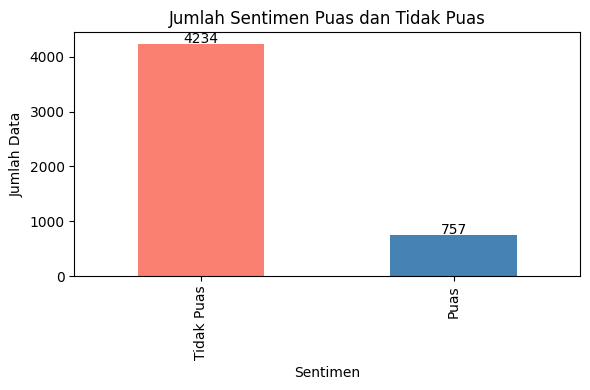

In [4]:
df['LikeReview'] = pd.to_numeric(df['LikeReview'], errors='coerce')
df = df.dropna(subset=['LikeReview'])
df['LikeReview'] = df['LikeReview'].astype(int)

def labeling(rating):
    if rating <= 3:
        return 'Tidak Puas'
    else:
        return 'Puas'

df['Sentimen'] = df['Rating'].apply(labeling)

# Encode label: Puas=1, Tidak Puas=0
label_map     = {'Tidak Puas': 0, 'Puas': 1}
label_map_inv = {0: 'Tidak Puas', 1: 'Puas'}
df['label_encoded'] = df['Sentimen'].map(label_map)

print('Distribusi Label:')
print(df['Sentimen'].value_counts())

# Visualisasi
sentimen_count = df['Sentimen'].value_counts()
plt.figure(figsize=(6, 4))
ax = sentimen_count.plot(kind='bar', color=['salmon', 'steelblue'])
plt.title('Jumlah Sentimen Puas dan Tidak Puas')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Data')
for i, (label, value) in enumerate(sentimen_count.items()):
    plt.text(i, value + 10, str(value), ha='center')
plt.tight_layout()
plt.show()

# ✂️ 5. Split Data (Train / Test)

> Split dilakukan **sekali** menggunakan indeks yang sama untuk TF-IDF dan IndoBERT agar perbandingan akurasi fair.

In [5]:
train_idx, test_idx = train_test_split(
    df.index, test_size=0.2, random_state=42, stratify=df['label_encoded']
)

df_train = df.loc[train_idx].reset_index(drop=True)
df_test  = df.loc[test_idx].reset_index(drop=True)

print(f'Data train : {len(df_train)} sampel')
print(f'Data test  : {len(df_test)} sampel')

Data train : 3992 sampel
Data test  : 999 sampel


# 📊 6. TF-IDF Vectorization & SMOTE

In [6]:
tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(df_train['Review_final'].astype(str))
X_test_tfidf  = tfidf.transform(df_test['Review_final'].astype(str))

y_train = df_train['Sentimen']
y_test  = df_test['Sentimen']

print(f'Ukuran matrix TF-IDF train : {X_train_tfidf.shape}')
print(f'Ukuran matrix TF-IDF test  : {X_test_tfidf.shape}')

# SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_tfidf, y_train)

print('\nDistribusi sebelum SMOTE:')
print(y_train.value_counts())
print('\nDistribusi setelah SMOTE:')
print(pd.Series(y_train_smote).value_counts())

Ukuran matrix TF-IDF train : (3992, 7321)
Ukuran matrix TF-IDF test  : (999, 7321)

Distribusi sebelum SMOTE:
Sentimen
Tidak Puas    3387
Puas           605
Name: count, dtype: int64

Distribusi setelah SMOTE:
Sentimen
Tidak Puas    3387
Puas          3387
Name: count, dtype: int64


# 🤖 7. Model SVM (Sebelum & Sesudah SMOTE)

In [7]:
# SVM Sebelum SMOTE
svm = SVC(kernel='linear')
svm.fit(X_train_tfidf, y_train)
y_pred_svm_before = svm.predict(X_test_tfidf)

print('===== SVM (SEBELUM SMOTE) =====')
print(f'Accuracy: {accuracy_score(y_test, y_pred_svm_before):.4f}')
print(classification_report(y_test, y_pred_svm_before))

# SVM + SMOTE
svm_smote = SVC(kernel='linear')
svm_smote.fit(X_train_smote, y_train_smote)
y_pred_svm_after = svm_smote.predict(X_test_tfidf)

print('\n===== SVM + SMOTE =====')
print(f'Accuracy: {accuracy_score(y_test, y_pred_svm_after):.4f}')
print(classification_report(y_test, y_pred_svm_after))

===== SVM (SEBELUM SMOTE) =====
Accuracy: 0.8919
              precision    recall  f1-score   support

        Puas       0.89      0.33      0.48       152
  Tidak Puas       0.89      0.99      0.94       847

    accuracy                           0.89       999
   macro avg       0.89      0.66      0.71       999
weighted avg       0.89      0.89      0.87       999


===== SVM + SMOTE =====
Accuracy: 0.8268
              precision    recall  f1-score   support

        Puas       0.45      0.61      0.52       152
  Tidak Puas       0.92      0.87      0.89       847

    accuracy                           0.83       999
   macro avg       0.69      0.74      0.70       999
weighted avg       0.85      0.83      0.84       999



# 🌳 8. Model Random Forest (Sebelum & Sesudah SMOTE)

In [8]:
# RF Sebelum SMOTE
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_tfidf, y_train)
y_pred_rf_before = rf.predict(X_test_tfidf)

print('===== RANDOM FOREST (SEBELUM SMOTE) =====')
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf_before):.4f}')
print(classification_report(y_test, y_pred_rf_before))

# RF + SMOTE
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_smote.fit(X_train_smote, y_train_smote)
y_pred_rf_after = rf_smote.predict(X_test_tfidf)

print('\n===== RANDOM FOREST + SMOTE =====')
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf_after):.4f}')
print(classification_report(y_test, y_pred_rf_after))

===== RANDOM FOREST (SEBELUM SMOTE) =====
Accuracy: 0.8859
              precision    recall  f1-score   support

        Puas       0.93      0.27      0.42       152
  Tidak Puas       0.88      1.00      0.94       847

    accuracy                           0.89       999
   macro avg       0.91      0.63      0.68       999
weighted avg       0.89      0.89      0.86       999


===== RANDOM FOREST + SMOTE =====
Accuracy: 0.8889
              precision    recall  f1-score   support

        Puas       0.77      0.39      0.52       152
  Tidak Puas       0.90      0.98      0.94       847

    accuracy                           0.89       999
   macro avg       0.83      0.68      0.73       999
weighted avg       0.88      0.89      0.87       999



# 🔍 9. Grid Search CV — Tuning Random Forest

In [10]:
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

rf_model = RandomForestClassifier(random_state=42)
grid_search_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid_rf,
    cv=5, n_jobs=-1, verbose=1, scoring='accuracy'
)
grid_search_rf.fit(X_train_smote, y_train_smote)

best_rf_model   = grid_search_rf.best_estimator_
y_pred_rf_tuned = best_rf_model.predict(X_test_tfidf)
acc_rf_tuned    = accuracy_score(y_test, y_pred_rf_tuned)

print(f'Best Params RF   : {grid_search_rf.best_params_}')
print(f'Accuracy Tuned RF: {acc_rf_tuned:.4f}')
print(classification_report(y_test, y_pred_rf_tuned))

# Simpan model TF-IDF
with open('model_tfidf_rf.pkl', 'wb') as f:
    pickle.dump(best_rf_model, f)
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print('\n✅ Model TF-IDF+RF tersimpan: model_tfidf_rf.pkl & tfidf_vectorizer.pkl')

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Params RF   : {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Accuracy Tuned RF: 0.8869
              precision    recall  f1-score   support

        Puas       0.77      0.37      0.50       152
  Tidak Puas       0.90      0.98      0.94       847

    accuracy                           0.89       999
   macro avg       0.83      0.67      0.72       999
weighted avg       0.88      0.89      0.87       999


✅ Model TF-IDF+RF tersimpan: model_tfidf_rf.pkl & tfidf_vectorizer.pkl


# 🤗 10. Fine-Tuning IndoBERT

> **Kenapa IndoBERT lebih baik dari TF-IDF?**
> - TF-IDF hanya melihat frekuensi kata, tidak paham makna
> - IndoBERT memahami **konteks kalimat** secara bidirectional
> - Contoh: *"pelayanannya ramah"* → IndoBERT tahu ini **Puas**, bukan Tidak Puas

> ⚠️ **Catatan:** IndoBERT **tidak** memerlukan stemming/stopword removal.
> Kita pakai `Review_normalized` (setelah normalisasi slang) agar model bisa membaca kata secara alami.

In [11]:
INDOBERT_MODEL = 'indobenchmark/indobert-base-p1'
MAX_LEN        = 128
BATCH_SIZE     = 16
EPOCHS         = 3
LEARNING_RATE  = 2e-5

print('Memuat tokenizer IndoBERT...')
bert_tokenizer = AutoTokenizer.from_pretrained(INDOBERT_MODEL)
print('✅ Tokenizer siap')

Memuat tokenizer IndoBERT...


config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

✅ Tokenizer siap


# 📋 11. Dataset Class (PyTorch)

In [12]:
class SentimenDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Buat dataset
train_texts  = df_train['Review_normalized'].astype(str).tolist()
test_texts   = df_test['Review_normalized'].astype(str).tolist()
train_labels = df_train['label_encoded'].tolist()
test_labels  = df_test['label_encoded'].tolist()

train_dataset = SentimenDataset(train_texts, train_labels, bert_tokenizer, MAX_LEN)
test_dataset  = SentimenDataset(test_texts,  test_labels,  bert_tokenizer, MAX_LEN)

print(f'Train dataset : {len(train_dataset)} sampel')
print(f'Test dataset  : {len(test_dataset)} sampel')

Train dataset : 3992 sampel
Test dataset  : 999 sampel


# 🏋️ 12. Load Model IndoBERT & Fine-Tuning

In [15]:
print('Memuat model IndoBERT untuk sequence classification (2 kelas)...')
bert_model = AutoModelForSequenceClassification.from_pretrained(
    INDOBERT_MODEL,
    num_labels=2,
    id2label=label_map_inv,
    label2id=label_map
)

training_args = TrainingArguments(
    output_dir='./indobert_results',
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy='epoch',        # ← ganti dari evaluation_strategy
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    logging_dir='./indobert_logs',
    logging_steps=50,
    report_to='none',
    fp16=torch.cuda.is_available(),
    seed=42
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {'accuracy': accuracy_score(labels, predictions)}

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print('\n🚀 Mulai fine-tuning IndoBERT...')
print('(~5-10 menit di GPU Colab T4, ~30-60 menit di CPU)')
trainer.train()
print('\n✅ Fine-tuning selesai!')

Memuat model IndoBERT untuk sequence classification (2 kelas)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.



🚀 Mulai fine-tuning IndoBERT...
(~5-10 menit di GPU Colab T4, ~30-60 menit di CPU)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.285132,0.252831,0.910911
2,0.172115,0.289490,0.898899
3,0.089730,0.389194,0.893894


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


✅ Fine-tuning selesai!


# 📈 13. Evaluasi IndoBERT

In [17]:
print('Evaluasi IndoBERT pada data test...')
bert_preds_output = trainer.predict(test_dataset)
bert_preds        = np.argmax(bert_preds_output.predictions, axis=-1)
bert_preds_labels = [label_map_inv[p] for p in bert_preds]
y_test_list       = df_test['Sentimen'].tolist()

acc_bert = accuracy_score(y_test_list, bert_preds_labels)
print(f'\nAccuracy IndoBERT: {acc_bert:.4f}')
print('\nClassification Report IndoBERT:')
print(classification_report(y_test_list, bert_preds_labels))
print('Confusion Matrix IndoBERT:')
print(confusion_matrix(y_test_list, bert_preds_labels))

# Simpan model
bert_model.save_pretrained('./indobert_model')
bert_tokenizer.save_pretrained('./indobert_model')
print('\n✅ Model IndoBERT tersimpan di folder: ./indobert_model')

Evaluasi IndoBERT pada data test...



Accuracy IndoBERT: 0.9119

Classification Report IndoBERT:
              precision    recall  f1-score   support

        Puas       0.75      0.64      0.69       152
  Tidak Puas       0.94      0.96      0.95       847

    accuracy                           0.91       999
   macro avg       0.84      0.80      0.82       999
weighted avg       0.91      0.91      0.91       999

Confusion Matrix IndoBERT:
[[ 97  55]
 [ 33 814]]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Model IndoBERT tersimpan di folder: ./indobert_model


# 🏆 14. Perbandingan Semua Model

Ranking Akurasi Model:
                    Model  Accuracy
    IndoBERT (Fine-tuned)    0.9119
             SVM (TF-IDF)    0.8919
      RF + SMOTE (TF-IDF)    0.8889
RF Tuned + SMOTE (TF-IDF)    0.8869
   Random Forest (TF-IDF)    0.8859
     SVM + SMOTE (TF-IDF)    0.8268


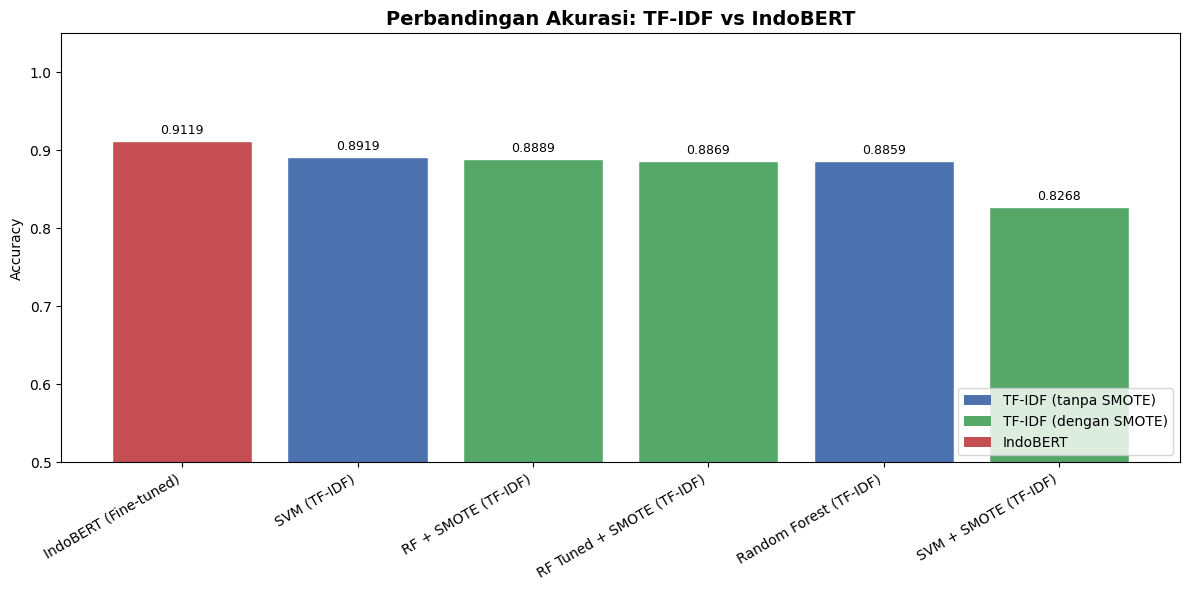

In [18]:
acc_svm_before = accuracy_score(y_test, y_pred_svm_before)
acc_rf_before  = accuracy_score(y_test, y_pred_rf_before)
acc_svm_after  = accuracy_score(y_test, y_pred_svm_after)
acc_rf_after   = accuracy_score(y_test, y_pred_rf_after)

comparison_data = {
    'Model': [
        'SVM (TF-IDF)',
        'Random Forest (TF-IDF)',
        'SVM + SMOTE (TF-IDF)',
        'RF + SMOTE (TF-IDF)',
        'RF Tuned + SMOTE (TF-IDF)',
        'IndoBERT (Fine-tuned)'
    ],
    'Accuracy': [
        acc_svm_before,
        acc_rf_before,
        acc_svm_after,
        acc_rf_after,
        acc_rf_tuned,
        acc_bert
    ]
}

df_comparison = pd.DataFrame(comparison_data).sort_values('Accuracy', ascending=False)
print('Ranking Akurasi Model:')
print(df_comparison.round(4).to_string(index=False))

# Plot
from matplotlib.patches import Patch
color_map = {
    'SVM (TF-IDF)': '#4C72B0',
    'Random Forest (TF-IDF)': '#4C72B0',
    'SVM + SMOTE (TF-IDF)': '#55A868',
    'RF + SMOTE (TF-IDF)': '#55A868',
    'RF Tuned + SMOTE (TF-IDF)': '#55A868',
    'IndoBERT (Fine-tuned)': '#C44E52'
}
colors = [color_map[m] for m in df_comparison['Model']]

plt.figure(figsize=(12, 6))
bars = plt.bar(df_comparison['Model'], df_comparison['Accuracy'], color=colors, edgecolor='white')
plt.title('Perbandingan Akurasi: TF-IDF vs IndoBERT', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy')
plt.xticks(rotation=30, ha='right')
plt.ylim(0.5, 1.05)
for bar, val in zip(bars, df_comparison['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', va='bottom', fontsize=9)
legend_elements = [
    Patch(facecolor='#4C72B0', label='TF-IDF (tanpa SMOTE)'),
    Patch(facecolor='#55A868', label='TF-IDF (dengan SMOTE)'),
    Patch(facecolor='#C44E52', label='IndoBERT')
]
plt.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

# 🎯 15. Fungsi Prediksi & Demo

Kedua model bisa dipakai sekaligus untuk membandingkan hasil prediksi.

In [19]:
def predict_with_tfidf(text):
    """Prediksi menggunakan TF-IDF + Random Forest (model lama)."""
    processed = case_folding(text)
    processed = cleaning(processed)
    processed = normalisasi_kata(processed)
    tokens    = tokenizing(processed)
    tokens    = stopword_removal(tokens)
    tokens    = stemming(tokens)
    final     = join_text(tokens)
    X_vec     = tfidf.transform([final])
    pred      = best_rf_model.predict(X_vec)[0]
    return pred, final

def predict_with_indobert(text):
    """Prediksi menggunakan IndoBERT (lebih paham konteks)."""
    processed = case_folding(text)
    processed = cleaning(processed)
    processed = normalisasi_kata(processed)

    bert_model.eval()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    bert_model.to(device)

    encoding = bert_tokenizer(
        processed,
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    input_ids      = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
        pred_id = torch.argmax(outputs.logits, dim=-1).item()

    return label_map_inv[pred_id], processed

# Demo
demo_reviews = [
    'pelayanannya ramah dan menyenangkan',
    'kereta telat 2 jam dan tidak ada penjelasan',
    'lumayan lah tapi kursinya agak sempit',
    'sangat puas dengan pelayanan petugas yang sopan',
    'mengecewakan, AC rusak dan petugas tidak responsif'
]

print(f"{'Review':<45} {'TF-IDF+RF':<15} {'IndoBERT':<15}")
print('-' * 75)
for review in demo_reviews:
    pred_tfidf, _ = predict_with_tfidf(review)
    pred_bert,  _ = predict_with_indobert(review)
    print(f'{review:<45} {pred_tfidf:<15} {pred_bert:<15}')

Review                                        TF-IDF+RF       IndoBERT       
---------------------------------------------------------------------------
pelayanannya ramah dan menyenangkan           Puas            Puas           
kereta telat 2 jam dan tidak ada penjelasan   Tidak Puas      Tidak Puas     
lumayan lah tapi kursinya agak sempit         Tidak Puas      Puas           
sangat puas dengan pelayanan petugas yang sopan Puas            Puas           
mengecewakan, AC rusak dan petugas tidak responsif Tidak Puas      Tidak Puas     


# ✍️ 16. Input Manual dari User

In [22]:
new_review = input('\nMasukkan ulasan yang ingin Anda uji: ')

pred_tfidf, processed_tfidf = predict_with_tfidf(new_review)
pred_bert,  processed_bert  = predict_with_indobert(new_review)

print(f'\nReview asli        : {new_review}')
print(f'\n[TF-IDF + RF]')
print(f'  Teks preprocessed: {processed_tfidf}')
print(f'  Prediksi Sentimen: {pred_tfidf}')
print(f'\n[IndoBERT]')
print(f'  Teks preprocessed: {processed_bert}')
print(f'  Prediksi Sentimen: {pred_bert}')

if pred_tfidf != pred_bert:
    print('\n⚠️  Kedua model berbeda prediksi.')
    print('   → IndoBERT lebih direkomendasikan karena memahami konteks kalimat.')
else:
    print(f'\n✅ Kedua model sepakat: {pred_bert}')


Masukkan ulasan yang ingin Anda uji: suka bgt sama eksekutifnya bisa selonjoran

Review asli        : suka bgt sama eksekutifnya bisa selonjoran

[TF-IDF + RF]
  Teks preprocessed: suka banget eksekutif selonjor
  Prediksi Sentimen: Tidak Puas

[IndoBERT]
  Teks preprocessed: suka banget sama eksekutifnya bisa selonjoran
  Prediksi Sentimen: Puas

⚠️  Kedua model berbeda prediksi.
   → IndoBERT lebih direkomendasikan karena memahami konteks kalimat.
